# 01: Synthetic event generation

This notebook inspects the frozen evaluation dataset produced by `python -m datagen`.
It shows what the event stream looks like, where the injected manipulation episodes sit,
and why each pattern is detectable in principle. The full modeling scope and its limits
are documented in `docs/SYNTHETIC.md`; the answer-key design decision is Decision 6 in
`docs/ADR.md`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("../eval/dataset")
events = pd.read_parquet(DATA / "events.parquet")
ground_truth = pd.DataFrame(json.loads((DATA / "ground_truth.json").read_text()))
manifest = json.loads((DATA / "manifest.json").read_text())

print(f"events: {len(events):,}")
print(f"episodes: {len(ground_truth)}")
print(f"sha256: {manifest['events_sha256'][:16]}...")
events.head()

events: 263,872
episodes: 42
sha256: e22b912a699db0e6...


,event_id,ts,event_type,order_id,account_id,instrument,venue,side,price,quantity,counterparty_id
0,0,0.111372,new,BRVO-0000000,ACCT-014,BRVO,XNAS,buy,132.11,74,NaN
1,1,0.202791,new,BRVO-0000001,ACCT-003,BRVO,XNAS,sell,132.21,106,NaN
2,2,0.361226,new,ALPH-F-0000000,ACCT-005,ALPH-F,XCME,sell,48.57,82,NaN
3,3,0.845189,new,ALPH-0000000,ACCT-023,ALPH,XNYS,sell,48.52,81,NaN
4,4,0.894759,new,ALPH-0000001,ACCT-020,ALPH,XNYS,buy,48.47,72,NaN


## Dataset shape

Four instruments on three venues, one 6.5 hour session. Background flow arrives at 1.5
new orders per second per instrument; 35 percent execute, 45 percent cancel, 20 percent
rest. The injected episodes are a rounding error by volume, which matches the real
surveillance problem: the signal is rare and the tape is mostly noise.

In [2]:
by_type = events.groupby(["instrument", "event_type"]).size().unstack(fill_value=0)
by_type["total"] = by_type.sum(axis=1)
display(by_type)

episode_order_ids = set(ground_truth["order_ids"].explode())
share = events["order_id"].isin(episode_order_ids).mean()
print(f"share of events belonging to injected episodes: {share:.2%}")
ground_truth.groupby("pattern").agg(
    episodes=("episode_id", "count"),
    mean_duration_s=("end_ts", lambda s: (s - ground_truth.loc[s.index, "start_ts"]).mean().round(1)),
)

event_type,cancel,execute,new,total
instrument,,,,
ALPH,15837,12299,35167,63303
ALPH-F,17747,12507,37389,67643
BRVO,17997,12168,37210,67375
CRUX,17079,12217,36255,65551


share of events belonging to injected episodes: 4.22%


,episodes,mean_duration_s
pattern,,
layering,14,36.0
quote_stuffing,6,8.1
spoofing,14,30.5
wash_trading,8,89.7


## Price path with episode windows

The mid proxy below is the per-minute median of new-order prices. Spoofing and layering
episodes displace the price toward the spoofed side while the non-bona-fide orders rest,
then the price reverts. Wash trading and quote stuffing leave the price alone by
construction.

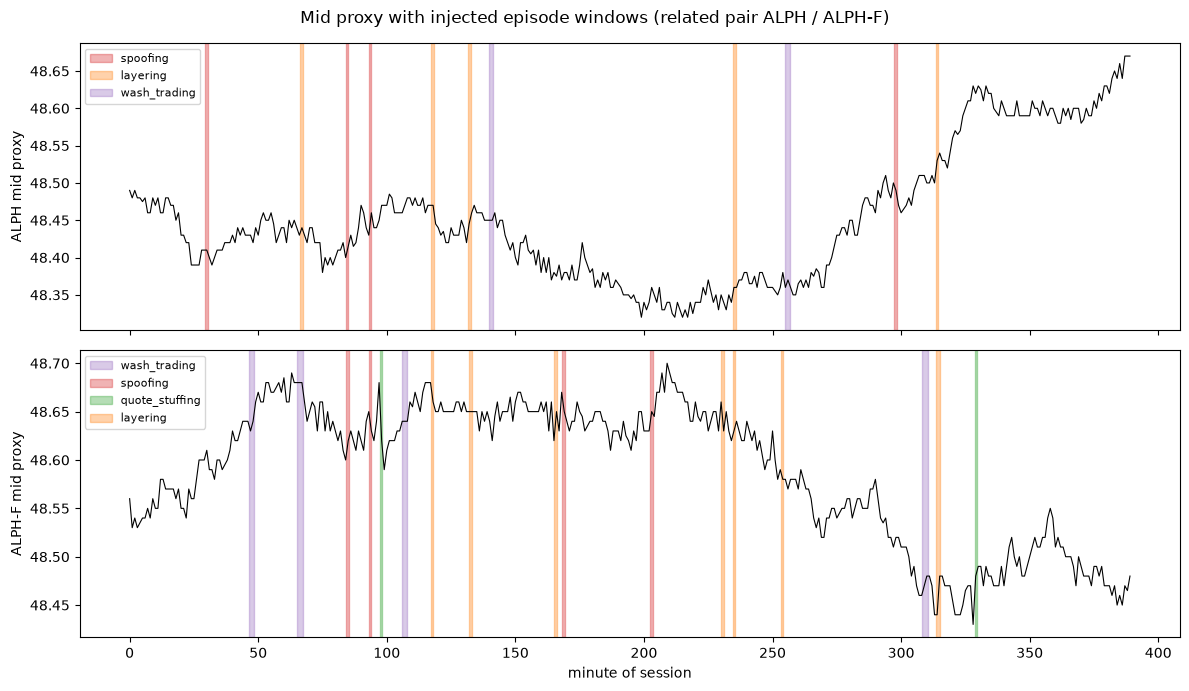

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
colors = {"spoofing": "tab:red", "layering": "tab:orange",
          "wash_trading": "tab:purple", "quote_stuffing": "tab:green"}

for ax, sym in zip(axes, ["ALPH", "ALPH-F"]):
    inst = events[(events.instrument == sym) & (events.event_type == "new")]
    mid = inst.set_index("ts")["price"].groupby(lambda t: int(t // 60)).median()
    ax.plot(mid.index, mid.values, lw=0.8, color="black")
    for _, ep in ground_truth[ground_truth.instrument == sym].iterrows():
        ax.axvspan(ep.start_ts / 60, ep.end_ts / 60 + 0.5, alpha=0.35,
                   color=colors[ep.pattern], label=ep.pattern)
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left", fontsize=8)
    ax.set_ylabel(f"{sym} mid proxy")
axes[1].set_xlabel("minute of session")
fig.suptitle("Mid proxy with injected episode windows (related pair ALPH / ALPH-F)")
fig.tight_layout()
plt.show()

## Anatomy of one spoofing episode

Large resting orders on one side, a small genuine fill on the other side at the displaced
price, then cancellation of the resting size within a second of the fill. This is the
intent-to-cancel structure of CEA 4c(a)(5)(C) made literal.

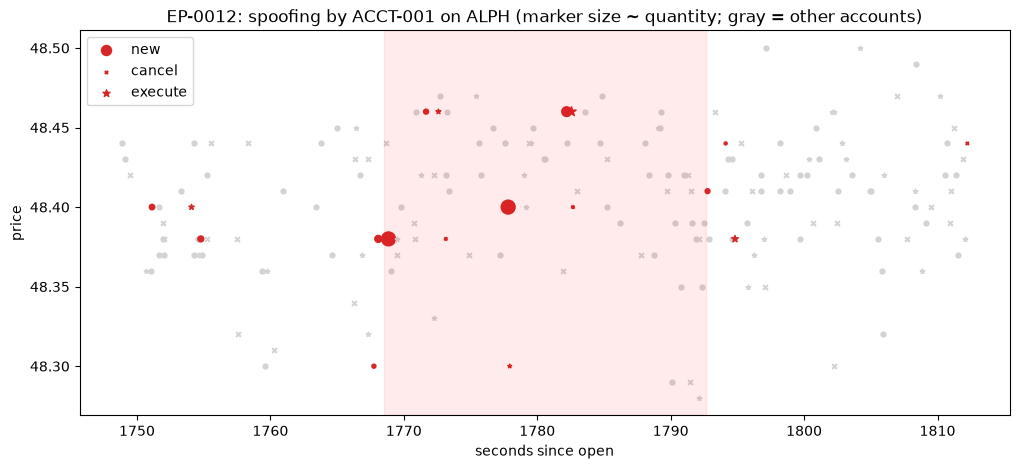

                ts event_type  side  price  quantity
18637  1751.126187        new  sell  48.40        63
18669  1754.086194    execute  sell  48.40        63
18679  1754.784145        new   buy  48.38        73
18800  1767.755332        new   buy  48.30        34
18803  1768.082393        new   buy  48.38       102
18811  1768.848000        new   buy  48.38      2617
18844  1771.664825        new  sell  48.46        52
18854  1772.593329    execute  sell  48.46        52
18863  1773.145455     cancel   buy  48.38         0
18895  1777.818324        new   buy  48.40      3126
18896  1777.934175    execute   buy  48.30        34
18932  1782.202064        new  sell  48.46       197


In [4]:
ep = ground_truth[ground_truth.pattern == "spoofing"].iloc[0]
pad = 20
win = events[(events.instrument == ep.instrument)
             & events.ts.between(ep.start_ts - pad, ep.end_ts + pad)]
mine = win[win.account_id == ep.account_ids[0]]
others = win[win.account_id != ep.account_ids[0]]

fig, ax = plt.subplots(figsize=(12, 5))
markers = {"new": "o", "cancel": "x", "execute": "*"}
for etype, m in markers.items():
    sub = others[others.event_type == etype]
    ax.scatter(sub.ts, sub.price, s=12, marker=m, color="lightgray")
    sub = mine[mine.event_type == etype]
    ax.scatter(sub.ts, sub.price, s=sub.quantity.clip(20, 400) / 4, marker=m,
               color="tab:red", label=etype)
ax.axvspan(ep.start_ts, ep.end_ts, alpha=0.08, color="red")
ax.set_xlabel("seconds since open")
ax.set_ylabel("price")
ax.set_title(f"{ep.episode_id}: spoofing by {ep.account_ids[0]} on {ep.instrument} "
             "(marker size ~ quantity; gray = other accounts)")
ax.legend()
plt.show()

print(mine[["ts", "event_type", "side", "price", "quantity"]].head(12).to_string())

## Cancel latency: the core spoofing signature

Benign cancels happen on a mean 40 second clock. Spoofing and layering cancels happen
within a second of the genuine fill. The detection layer thresholds on exactly this gap.

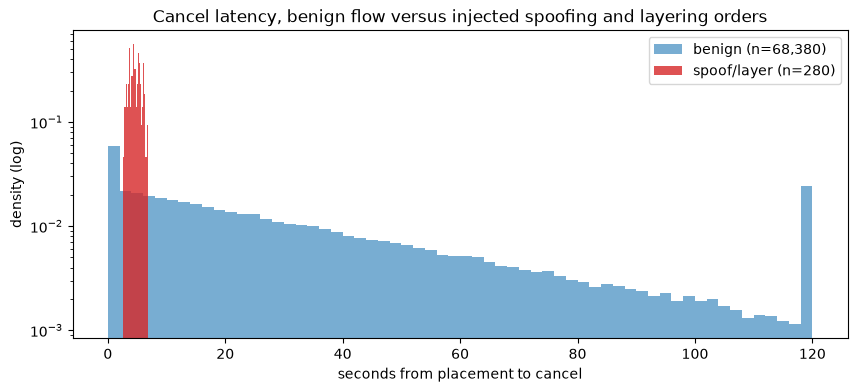

benign median: 24.5s | injected median: 4.55s


In [5]:
news = events[events.event_type == "new"].set_index("order_id")["ts"]
cxls = events[events.event_type == "cancel"].set_index("order_id")["ts"]
latency = (cxls - news.reindex(cxls.index)).dropna()

spoof_layer_ids = set(
    ground_truth[ground_truth.pattern.isin(["spoofing", "layering"])]["order_ids"].explode()
)
is_injected = latency.index.isin(spoof_layer_ids)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(latency[~is_injected].clip(upper=120), bins=60, alpha=0.6,
        label=f"benign (n={(~is_injected).sum():,})", density=True)
ax.hist(latency[is_injected].clip(upper=120), bins=60, alpha=0.8,
        label=f"spoof/layer (n={is_injected.sum()})", density=True, color="tab:red")
ax.set_yscale("log")
ax.set_xlabel("seconds from placement to cancel")
ax.set_ylabel("density (log)")
ax.set_title("Cancel latency, benign flow versus injected spoofing and layering orders")
ax.legend()
plt.show()

print(f"benign median: {latency[~is_injected].median():.1f}s | "
      f"injected median: {latency[is_injected].median():.2f}s")

## Quote stuffing: message rate

A stuffing burst pushes an account's message rate two orders of magnitude above the
background. The detector looks at per-second message counts per account and instrument.

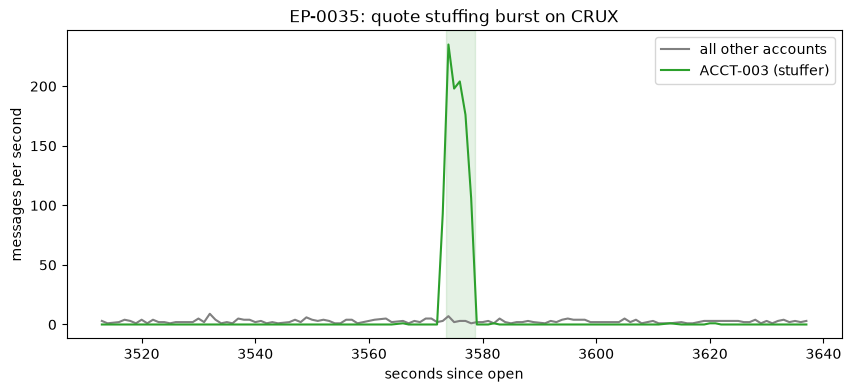

In [6]:
ep = ground_truth[ground_truth.pattern == "quote_stuffing"].iloc[0]
pad = 60
win = events[(events.instrument == ep.instrument)
             & events.ts.between(ep.start_ts - pad, ep.end_ts + pad)]
rate = win.groupby([win.ts.astype(int), "account_id"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
stuffer = ep.account_ids[0]
ax.plot(rate.index, rate.drop(columns=[stuffer], errors="ignore").sum(axis=1),
        label="all other accounts", color="gray")
if stuffer in rate.columns:
    ax.plot(rate.index, rate[stuffer], label=f"{stuffer} (stuffer)", color="tab:green")
ax.axvspan(ep.start_ts, ep.end_ts, alpha=0.1, color="green")
ax.set_xlabel("seconds since open")
ax.set_ylabel("messages per second")
ax.set_title(f"{ep.episode_id}: quote stuffing burst on {ep.instrument}")
ax.legend()
plt.show()

## Caveats

This is a stylized event stream, not a matching engine, and the injected patterns are
detectable by construction. Every recall or precision number computed downstream is a
statement about this generator's answer key, not about performance on a real venue.
`docs/SYNTHETIC.md` lists everything that is deliberately not modeled.